# Imports e Datasets

Os dataset utilizados no presente notebook são o DoH-Tunnel-Traffic-HKD dataset, disponível em https://github.com/doh-traffic-dataset/DoH-Tunnel-Traffic-HKD/, e o CIRA-CIC-DoHBrw-2020-and-DoH-Tunnel-Traffic-HKD, disponível em https://github.com/doh-traffic-dataset/CIRA-CIC-DoHBrw-2020-and-DoH-Tunnel-Traffic-HKD/

O segundo dataset é formado pela junção do CIRA-CIC-DoHBrw-2020, artigo originalmente utilizado no artigo trabalhado, com o DoH-Tunnel-Traffic-HKD, que acrescenta instâncias de ataques geradas por 3 novas ferramentas de tunneling.

## Configs

In [ ]:
pip install imbalanced-learn

In [ ]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 667, done.
remote: Counting objects: 100% (233/233), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 667 (delta 174), reused 100 (delta 97), pack-reused 434 (from 3)
Receiving objects: 100% (667/667), 220.60 KiB | 15.76 MiB/s, done.
Resolving deltas: 100% (348/348), done.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.12.13 environment at: /usr
Resolved 180 packages in 9.30s
Prepared 10 packages in 5.46s
Uninstalled 4 packages in 714ms
Installed 10 packages in 166ms
 - bokeh==3.8.2
 + bokeh==3.6.3
 + cugraph-cu12==26.2.0
 + cuxfilter-cu12==26.2.0
 + datashader==0.19.1
 - holoviews==1.22.1
 + holoviews==1.20.2
 + jupyter-server-proxy==4.5.0
 - panel==1.9.3
 + panel==1.7.5
 + pyct==0.6.0
 - shapely==2.1.2
 + shapely==2.0.7
 + simpervisor==1.0.0

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do

In [ ]:
!pip install shap

In [ ]:
from google.colab import drive
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cupy as cp
import cudf
import shap

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler as ScalerCPU
from cuml.preprocessing import MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.model_selection import GridSearchCV

from cuml.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier as RandomForestCPU
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*DataFrame.swapaxes.*"
)

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Acessando os arquivos doS datasets no Google Drive

caminho_base = '/content/drive/MyDrive/Datasets/Detecção de Intrusão'

df_hkd = pd.read_csv(caminho_base + '/DoH-Tunnel-Traffic-HKD/Total-48h-Augmentation.csv')
df_cira_l1 = pd.read_csv(caminho_base + '/CIRA-CIC-DoHBrw-2020-and-DoH-Tunnel-Traffic-HKD/l1-total-add.csv')
df_cira_l2 = pd.read_csv(caminho_base + '/CIRA-CIC-DoHBrw-2020-and-DoH-Tunnel-Traffic-HKD/l2-total-add.csv')
df_cira_l3 = pd.read_csv(caminho_base + '/CIRA-CIC-DoHBrw-2020-and-DoH-Tunnel-Traffic-HKD/l3-total-add.csv')

## Dataset 1: DoH-Tunnel-Traffic-HKD

In [ ]:
print(f'Shape HKD: {df_hkd.shape}\n')
df_hkd.head()

Shape HKD: (105160, 35)



,SourceIP,DestinationIP,SourcePort,DestinationPort,TimeStamp,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,...,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation,Label
0,192.168.11.12,192.168.11.16,36912,443,2021/11/1 9:46,120.060446,105328,877.291427,111107,925.425514,...,1.153777,0.086813,0.294641,0.098283,0.000135,0.000011,0.999327,0.333530,2.997897,dnstt
1,192.168.11.12,192.168.11.16,36914,443,2021/11/1 9:46,0.045903,1057,23026.817420,5497,119752.521600,...,1.164993,0.000004,0.002036,0.001068,0.000047,0.000027,1.504693,0.511387,1.906038,dnstt
2,192.168.11.12,192.168.11.16,36912,443,2021/11/1 9:48,120.000088,53867,448.891338,48282,402.349705,...,0.607349,0.141739,0.376482,0.171586,0.000228,0.000111,1.365463,0.455465,2.194138,dnstt
3,192.168.11.12,192.168.11.16,36912,443,2021/11/1 9:50,59.933247,25968,433.282048,24025,400.862646,...,0.624972,0.147875,0.384546,0.180808,0.000251,0.000034,1.408599,0.470097,2.126820,dnstt
4,192.168.11.12,192.168.11.16,36918,443,2021/11/1 9:51,0.051581,991,19212.500730,5497,106570.248700,...,1.108618,0.000009,0.002918,0.001519,0.000081,0.000015,1.478279,0.515379,1.921156,dnstt


In [ ]:
df_hkd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105160 entries, 0 to 105159
Data columns (total 35 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   SourceIP                                105160 non-null  object 
 1   DestinationIP                           105160 non-null  object 
 2   SourcePort                              105160 non-null  int64  
 3   DestinationPort                         105160 non-null  int64  
 4   TimeStamp                               105160 non-null  object 
 5   Duration                                105160 non-null  float64
 6   FlowBytesSent                           105160 non-null  int64  
 7   FlowSentRate                            105160 non-null  float64
 8   FlowBytesReceived                       105160 non-null  int64  
 9   FlowReceivedRate                        105160 non-null  float64
 10  PacketLengthVariance                    1051

In [ ]:
df_hkd.describe()

,SourcePort,DestinationPort,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,...,PacketTimeSkewFromMode,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation
count,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,...,105160.000000,105160.000000,1.051600e+05,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000,105160.000000
mean,27939.329973,14682.829403,98.551564,31982.124192,2382.879016,32862.951312,11147.321834,35514.210578,142.368246,179.867196,...,1.317499,0.710744,2.680492e-01,0.361643,0.222314,0.000452,0.000294,1.453524,0.547411,1.590050
std,17894.735143,23029.241489,40.378793,28536.368501,5948.694099,28332.230517,31237.386129,70956.430183,123.473228,64.458120,...,0.689084,0.234162,3.546628e-01,0.370493,0.261047,0.001494,0.001194,0.619080,0.505244,1.039697
min,443.000000,443.000000,0.041714,198.000000,74.564279,132.000000,49.709519,0.000000,0.000000,66.000000,...,-1.980231,0.351095,6.410000e-10,0.000025,0.000095,0.000013,-0.000001,-2.164034,-2.137195,0.017108
25%,443.000000,443.000000,88.416775,13900.000000,124.866388,16776.000000,143.007163,6524.961102,80.777231,143.351852,...,0.870248,0.580048,1.000000e-07,0.000321,0.000450,0.000095,0.000042,1.274765,0.469380,0.525066
50%,37168.000000,443.000000,120.064498,21375.000000,356.653492,21723.500000,327.377440,8547.762054,92.454108,148.561246,...,1.641071,0.598754,9.716145e-02,0.311707,0.110625,0.000202,0.000086,1.462424,0.588013,1.489902
75%,40132.000000,34306.000000,120.404270,43156.000000,451.974815,39527.000000,412.833257,17886.559320,133.740642,198.862745,...,1.723993,0.729806,7.486813e-01,0.865264,0.579608,0.000255,0.000212,1.976645,0.714465,2.083558
max,58730.000000,58730.000000,122.988597,110740.000000,27125.561770,113979.000000,135790.719800,259846.415200,509.751327,377.764706,...,2.848234,1.402030,1.376642e+00,1.173304,0.834150,0.009971,0.009900,2.252535,3.848366,10.909276


In [ ]:
# Checando se existem valores faltantes

faltantes = df_hkd.isnull().sum()
faltantes[faltantes > 0].sort_values(ascending=False)

,0


In [ ]:
# Confirmando a quantidade de instâncias por classe

df_hkd['Label'].value_counts()

,count
Label,
dnstt,46080
tcp-over-dns,30040
tuns,29040


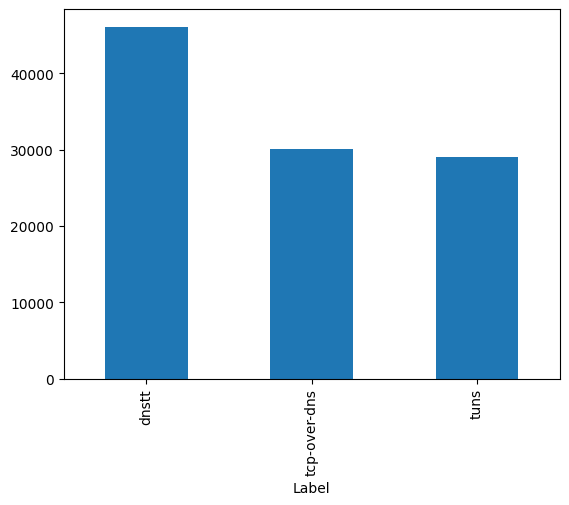

In [ ]:
# Visualizando a distribuição de classes

df_hkd['Label'].value_counts().plot(kind='bar')
plt.show()

## Dataset 2: CIRA-CIC-DoHBrw-2020-and-DoH-Tunnel-Traffic-HKD

### Layer 1

In [ ]:
print(f'Shape CIRA-CIC (layer 1): {df_cira_l1.shape}\n')
df_cira_l1.head()

Shape CIRA-CIC (layer 1): (1272296, 35)



,SourceIP,DestinationIP,SourcePort,DestinationPort,TimeStamp,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,...,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation,Label
0,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:49,95.081550,62311.0,655.342703,65358.0,687.388878,...,0.574626,0.001053,0.032457,0.027624,0.026854,0.026822,0.071187,0.024715,1.174948,DoH
1,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:50,122.309318,93828.0,767.136973,101232.0,827.672018,...,0.509047,0.001170,0.034200,0.024387,0.021043,0.026981,0.293297,-0.075845,1.402382,DoH
2,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:52,120.958413,38784.0,320.639127,38236.0,316.108645,...,0.732636,0.000785,0.028021,0.029238,0.026922,0.026855,0.248064,0.085061,0.958348,DoH
3,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:54,110.501080,61993.0,561.017141,69757.0,631.278898,...,0.646859,0.000411,0.020274,0.019925,0.019268,0.026918,0.097199,-0.344926,1.017535,DoH
4,176.103.130.131,192.168.20.191,443,50749,2020/1/14 15:56,54.229891,83641.0,1542.341289,76804.0,1416.266907,...,0.507334,0.079079,0.281209,0.025930,0.000046,0.000021,0.276133,0.092135,10.844829,DoH


In [ ]:
df_cira_l1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272296 entries, 0 to 1272295
Data columns (total 35 columns):
 #   Column                                  Non-Null Count    Dtype  
---  ------                                  --------------    -----  
 0   SourceIP                                1272296 non-null  object 
 1   DestinationIP                           1272296 non-null  object 
 2   SourcePort                              1272296 non-null  int64  
 3   DestinationPort                         1272296 non-null  int64  
 4   TimeStamp                               1272296 non-null  object 
 5   Duration                                1272296 non-null  float64
 6   FlowBytesSent                           1272296 non-null  float64
 7   FlowSentRate                            1272296 non-null  float64
 8   FlowBytesReceived                       1272296 non-null  float64
 9   FlowReceivedRate                        1272296 non-null  float64
 10  PacketLengthVariance          

In [ ]:
df_cira_l1.describe()

,SourcePort,DestinationPort,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,...,PacketTimeSkewFromMode,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation
count,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,...,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.272296e+06,1.264268e+06,1.272296e+06,1.264268e+06,1.272296e+06,1.272296e+06
mean,4.701715e+04,4.265724e+03,2.677136e+01,1.847828e+04,9.174672e+03,4.918816e+04,2.246884e+04,3.191018e+05,3.541287e+02,2.736310e+02,...,1.075829e+00,9.873906e-01,1.389162e+00,2.461090e-01,2.457471e-01,1.944654e-01,9.470233e-02,-2.328079e+00,-1.533533e+00,8.818795e-01
std,1.598863e+04,1.334958e+04,4.103292e+01,9.646869e+04,2.406445e+05,3.410095e+05,1.768635e+05,1.047763e+06,4.401077e+02,2.909626e+02,...,1.003400e+00,5.830330e-01,1.169127e+01,1.158107e+00,1.427964e+00,1.566873e+00,1.150604e+00,4.407288e+00,4.678284e+00,1.528020e+00
min,4.430000e+02,4.430000e+02,0.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,5.400000e+01,...,-1.000000e+01,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,2.000000e-06,-1.000000e+00,-1.000000e+01,-1.000000e+01,0.000000e+00
25%,4.088000e+04,4.430000e+02,9.941200e-02,2.170000e+02,1.151594e+02,1.780000e+02,2.098167e+02,2.708163e+02,1.645650e+01,7.152174e+01,...,6.295662e-01,5.791931e-01,0.000000e+00,1.327000e-05,1.287514e-02,1.202700e-02,2.400000e-05,-2.376928e+00,0.000000e+00,6.333525e-04
50%,5.151000e+04,4.430000e+02,2.671803e+00,1.644000e+03,9.381314e+02,4.708000e+03,1.792717e+03,5.180853e+04,2.276149e+02,2.107147e+02,...,1.000000e+00,8.884187e-01,5.786000e-05,7.606720e-03,2.161540e-02,1.714950e-02,1.570000e-04,-6.744323e-01,7.264857e-01,6.032968e-01
75%,5.755300e+04,4.430000e+02,3.407244e+01,3.256000e+03,3.662028e+03,1.142000e+04,6.508779e+03,2.990344e+05,5.468404e+02,3.377857e+02,...,1.665929e+00,1.200598e+00,4.372900e-04,2.091151e-02,5.981526e-02,2.809600e-02,2.103900e-02,9.580313e-01,1.264844e+00,1.072318e+00
max,6.553400e+04,6.553400e+04,1.790211e+02,1.597561e+07,9.436036e+07,5.268011e+07,3.044444e+07,8.109299e+07,9.005165e+03,5.146276e+03,...,2.280171e+01,8.777577e+00,1.002920e+03,3.166891e+01,4.501364e+01,4.501364e+01,4.501364e+01,2.970716e+00,7.096569e+00,7.366547e+01


In [ ]:
# Checando se existem valores faltantes

missing = df_cira_l1.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

,0
ResponseTimeTimeMedian,8028
ResponseTimeTimeSkewFromMedian,8028


In [ ]:
# Confirmando a quantidade de instâncias por classe

df_cira_l1['Label'].value_counts()

,count
Label,
NonDoH,897493
DoH,374803


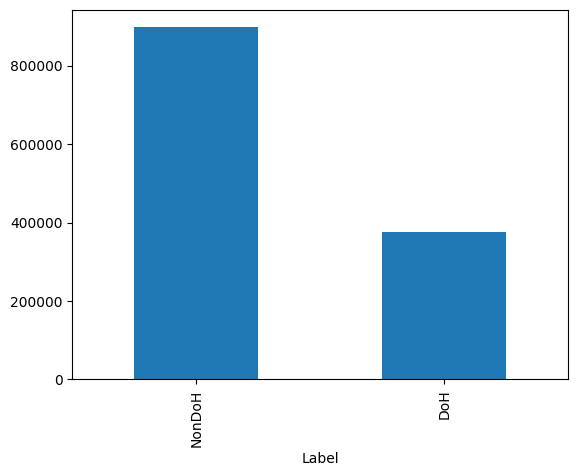

In [ ]:
# Visualizando a distribuição de classes

df_cira_l1['Label'].value_counts().plot(kind='bar')
plt.show()

### Layer 2

In [ ]:
print(f'Shape CIRA-CIC (layer 2): {df_cira_l2.shape}\n')
df_cira_l2.head()

Shape CIRA-CIC (layer 2): (374803, 35)



,SourceIP,DestinationIP,SourcePort,DestinationPort,TimeStamp,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,...,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation,Label
0,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:49,95.081550,62311,655.342703,65358,687.388878,...,0.574626,0.001053,0.032457,0.027624,0.026854,0.026822,0.071187,0.024715,1.174948,Benign
1,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:50,122.309318,93828,767.136973,101232,827.672018,...,0.509047,0.001170,0.034200,0.024387,0.021043,0.026981,0.293297,-0.075845,1.402382,Benign
2,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:52,120.958413,38784,320.639127,38236,316.108645,...,0.732636,0.000785,0.028021,0.029238,0.026922,0.026855,0.248064,0.085061,0.958348,Benign
3,192.168.20.191,176.103.130.131,50749,443,2020/1/14 15:54,110.501080,61993,561.017141,69757,631.278898,...,0.646859,0.000411,0.020274,0.019925,0.019268,0.026918,0.097199,-0.344926,1.017535,Benign
4,176.103.130.131,192.168.20.191,443,50749,2020/1/14 15:56,54.229891,83641,1542.341289,76804,1416.266907,...,0.507334,0.079079,0.281209,0.025930,0.000046,0.000021,0.276133,0.092135,10.844829,Benign


In [ ]:
df_cira_l2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374803 entries, 0 to 374802
Data columns (total 35 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   SourceIP                                374803 non-null  object 
 1   DestinationIP                           374803 non-null  object 
 2   SourcePort                              374803 non-null  int64  
 3   DestinationPort                         374803 non-null  int64  
 4   TimeStamp                               374803 non-null  object 
 5   Duration                                374803 non-null  float64
 6   FlowBytesSent                           374803 non-null  int64  
 7   FlowSentRate                            374803 non-null  float64
 8   FlowBytesReceived                       374803 non-null  int64  
 9   FlowReceivedRate                        374803 non-null  float64
 10  PacketLengthVariance                    3748

In [ ]:
df_cira_l2.describe()

,SourcePort,DestinationPort,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,...,PacketTimeSkewFromMode,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation
count,374803.000000,374803.000000,374803.000000,3.748030e+05,3.748030e+05,3.748030e+05,3.748030e+05,3.748030e+05,374803.000000,374803.000000,...,374803.000000,374803.000000,374803.000000,374803.000000,374803.000000,374459.000000,374803.000000,374459.000000,374803.000000,374803.000000
mean,35441.208104,10478.447873,66.399486,5.628129e+04,6.573205e+03,5.768292e+04,8.204965e+03,1.030302e+05,255.109434,196.765227,...,1.164469,0.985061,1.185417,0.318592,0.544467,0.515928,0.268106,0.089798,0.703075,1.415651
std,19536.835857,19725.425999,48.508460,1.627433e+05,1.458519e+05,1.560709e+05,8.723207e+04,1.319524e+05,194.806355,74.215107,...,0.719678,0.525774,7.339394,1.041996,2.342571,2.703236,1.986532,1.840416,1.299779,1.893179
min,443.000000,443.000000,0.000000,5.500000e+01,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000,55.000000,...,-10.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000002,-1.000000,-10.000000,-10.000000,0.000000
25%,34516.000000,443.000000,33.356912,1.738000e+03,5.491417e+01,4.827000e+03,1.436446e+02,6.615832e+03,81.337762,142.573827,...,0.624352,0.580289,0.000046,0.006749,0.010229,0.000222,0.000018,-1.426219,0.462386,0.654650
50%,40394.000000,443.000000,53.057304,4.257000e+03,2.026390e+02,6.931000e+03,2.656538e+02,2.780000e+04,166.733315,203.756098,...,1.169240,0.682558,0.000100,0.010005,0.014755,0.015019,0.000039,0.591582,0.717179,0.921182
75%,48988.000000,443.000000,120.063826,3.226600e+04,8.607459e+02,3.874200e+04,1.500651e+03,1.456134e+05,381.593277,228.862069,...,1.719220,1.588640,0.088924,0.298202,0.108998,0.015476,0.000179,1.434036,1.242012,1.632874
max,65532.000000,65497.000000,179.021144,8.015359e+06,2.304348e+07,7.723184e+06,7.600000e+06,1.578115e+06,1256.230616,689.800000,...,12.956406,5.616085,647.245330,25.441017,28.017596,28.017596,28.017596,2.970716,5.428781,66.309747


In [ ]:
# Checando se existem valores faltantes

faltantes = df_cira_l2.isnull().sum()
faltantes[faltantes > 0].sort_values(ascending=False)

,0
ResponseTimeTimeMedian,344
ResponseTimeTimeSkewFromMedian,344


In [ ]:
# Confirmando a quantidade de instâncias por classe

df_cira_l2['Label'].value_counts()

,count
Label,
Malicious,354996
Benign,19807


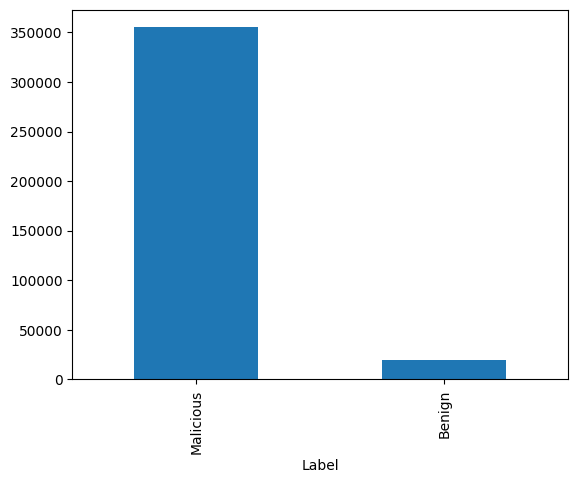

In [ ]:
# Visualizando a distribuição de classes

df_cira_l2['Label'].value_counts().plot(kind='bar')
plt.show()

### Layer 3

In [ ]:
print(f'Shape CIRA-CIC (layer 3): {df_cira_l3.shape}\n')
df_cira_l3.head()

Shape CIRA-CIC (layer 3): (354996, 35)



,SourceIP,DestinationIP,SourcePort,DestinationPort,TimeStamp,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,...,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation,Label
0,192.168.20.209,1.1.1.1,39406,443,2020/4/1 22:55,120.772871,42357.0,350.716180,71915.0,595.456574,...,0.489724,4.023502e-01,0.634311,0.163861,0.001734,0.000006,0.766785,0.258319,3.871039,dns2tcp
1,1.1.1.1,192.168.20.209,443,39406,2020/4/1 22:57,120.656643,78950.0,654.336123,46138.0,382.390881,...,0.617101,1.000000e-08,0.000112,0.000050,0.000034,0.000021,0.433249,0.260983,2.225769,dns2tcp
2,1.1.1.1,192.168.20.209,443,39406,2020/4/1 22:59,120.692061,78559.0,650.904453,46805.0,387.805127,...,0.617322,1.000000e-08,0.000095,0.000046,0.000031,0.000024,0.471856,0.231073,2.065863,dns2tcp
3,1.1.1.1,192.168.20.209,443,39406,2020/4/1 23:01,120.644016,78133.0,647.632619,46444.0,384.967291,...,0.608922,1.000000e-08,0.000088,0.000048,0.000035,0.000021,0.444360,0.307892,1.826318,dns2tcp
4,1.1.1.1,192.168.20.209,443,39406,2020/4/1 23:03,120.883686,79169.0,654.918812,47193.0,390.400074,...,0.615777,1.000000e-08,0.000114,0.000048,0.000030,0.000018,0.470369,0.261599,2.387701,dns2tcp


In [ ]:
df_cira_l3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354996 entries, 0 to 354995
Data columns (total 35 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   SourceIP                                354996 non-null  object 
 1   DestinationIP                           354996 non-null  object 
 2   SourcePort                              354996 non-null  int64  
 3   DestinationPort                         354996 non-null  int64  
 4   TimeStamp                               354996 non-null  object 
 5   Duration                                354996 non-null  float64
 6   FlowBytesSent                           354996 non-null  float64
 7   FlowSentRate                            354996 non-null  float64
 8   FlowBytesReceived                       354996 non-null  float64
 9   FlowReceivedRate                        354996 non-null  float64
 10  PacketLengthVariance                    3549

In [ ]:
df_cira_l3.describe()

,SourcePort,DestinationPort,Duration,FlowBytesSent,FlowSentRate,FlowBytesReceived,FlowReceivedRate,PacketLengthVariance,PacketLengthStandardDeviation,PacketLengthMean,...,PacketTimeSkewFromMode,PacketTimeCoefficientofVariation,ResponseTimeTimeVariance,ResponseTimeTimeStandardDeviation,ResponseTimeTimeMean,ResponseTimeTimeMedian,ResponseTimeTimeMode,ResponseTimeTimeSkewFromMedian,ResponseTimeTimeSkewFromMode,ResponseTimeTimeCoefficientofVariation
count,354996.000000,354996.000000,354996.000000,3.549960e+05,3.549960e+05,3.549960e+05,3.549960e+05,3.549960e+05,354996.000000,354996.000000,...,354996.000000,354996.000000,354996.000000,354996.000000,354996.000000,354713.000000,354996.000000,354713.000000,354996.000000,354996.000000
mean,35047.433478,10726.815984,68.280116,5.885874e+04,1.786041e+03,6.016709e+04,5.320766e+03,1.060223e+05,262.256182,200.072924,...,1.152693,0.993969,1.140229,0.317131,0.565223,0.543723,0.282765,0.182299,0.798960,1.447083
std,19598.757618,19921.748315,47.466337,1.666955e+05,5.131979e+04,1.597140e+05,2.560272e+04,1.297486e+05,192.987206,72.352397,...,0.699667,0.528694,6.678474,1.020419,2.400880,2.774773,2.040136,1.570652,0.783809,1.921880
min,443.000000,443.000000,0.000000,5.600000e+01,-1.000000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000,58.000000,...,-10.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000002,-1.000000,-10.000000,-10.000000,0.000000
25%,34260.000000,443.000000,33.506892,1.739000e+03,5.449072e+01,4.828000e+03,1.436630e+02,7.041419e+03,83.913165,143.351852,...,0.623314,0.580725,0.000048,0.006932,0.010166,0.000216,0.000019,-1.393735,0.464234,0.672661
50%,40110.000000,443.000000,59.908679,5.882000e+03,1.926482e+02,8.700000e+03,2.518672e+02,3.184122e+04,178.441080,213.718750,...,1.142853,0.668966,0.000107,0.010342,0.014549,0.014969,0.000039,0.620728,0.714980,0.950086
75%,48542.000000,443.000000,120.067238,3.793200e+04,8.376225e+02,3.942300e+04,1.286224e+03,1.456173e+05,381.598369,234.500000,...,1.719076,1.592232,0.092073,0.303435,0.112481,0.015444,0.000167,1.435136,1.243687,1.647804
max,60998.000000,60996.000000,135.088394,8.015359e+06,2.304348e+07,7.723184e+06,7.600000e+06,1.338915e+06,1157.114987,559.673469,...,5.808751,5.004242,62.142870,7.883075,28.017596,28.017596,28.017596,2.970716,5.428781,66.309747


In [ ]:
# Checando se existem valores faltantes

faltantes = df_cira_l3.isnull().sum()
faltantes[faltantes > 0].sort_values(ascending=False)

,0
ResponseTimeTimeMedian,283
ResponseTimeTimeSkewFromMedian,283


In [ ]:
# Confirmando a quantidade de instâncias por classe

df_cira_l3['Label'].value_counts()

,count
Label,
dns2tcp,167486
iodine,46580
dnstt,46080
dnscat2,35770
tcp-over-dns,30040
tuns,29040


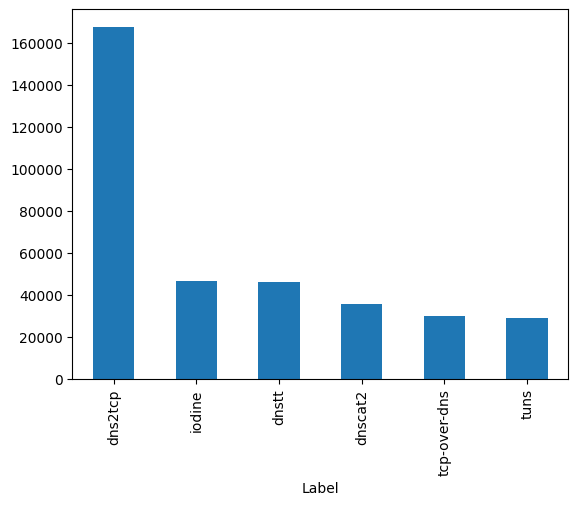

In [ ]:
# Visualizando a distribuição de classes

df_cira_l3['Label'].value_counts().plot(kind='bar')
plt.show()

## Pré-Processamento

### Limpeza

O HKD não possui valores faltantes, como pudemos observar na análise exploratória dos dados. Entretanto, sua junção com o CIRA-CIC possui valores faltantes nas 3 camadas. Como os autores não mencionam como foi realizado o tratamento desses valores, optamos por remover essas instâncias, visto que a quantidade é pouco significativa.

In [ ]:
# Deletando as instâncias que possuem valores faltantes

df_cira_l1 = df_cira_l1.dropna()
df_cira_l2 = df_cira_l2.dropna()
df_cira_l3 = df_cira_l3.dropna()

No trabalho original, os autores juntam os layers 1 e 2 no dataset CIRA-CIC, unificando as labels. Isso significa que as instâncias DoH no layer 1 (que classifica ataques como DoH ou non-DoH) possuem a classificação "detalhada" no layer 2: as instâncias DoH são anotadas como Normal DoH ou Suspicious DoH. Para juntar os dois datasets, vamos concatenar a segunda camada do dataset apenas às instâncias non-DoH do primeiro, de forma a evitar duplicatas.

Adicionalmente, já que estamos usando uma versão ainda mais detalhada do CIRA-CIC que possui uma terceira camada, nossa proposta de mudança na arquitetura para o presente trabalho inclui uma nova estrutura do dataset: uniremos as instâncias non-DoH da camada 1 às instâncias Normal DoH da camada 2 e à camada 3 completa, que corresponde aos ataques maliciosos de fato.

In [ ]:
# Removendo as colunas irrelevantes para a análise, conforme metodologia do artigo (que fica com 29 features no final)

colunas_irrelevantes = ['SourceIP', 'DestinationIP', 'SourcePort', 'DestinationPort', 'TimeStamp']

df_hkd_limpo = df_hkd.drop(columns=colunas_irrelevantes)
df_cira_l1_limpo = df_cira_l1.drop(columns=colunas_irrelevantes)
df_cira_l2_limpo = df_cira_l2.drop(columns=colunas_irrelevantes)
df_cira_l3_limpo = df_cira_l3.drop(columns=colunas_irrelevantes)

In [ ]:
non_doh = df_cira_l1_limpo[df_cira_l1_limpo['Label'] == 'NonDoH']
normal_doh = df_cira_l2_limpo[df_cira_l2_limpo['Label'] == 'Benign']

df_cira_l1_l2 = pd.concat([non_doh, df_cira_l2_limpo])
df_cira_l1_l2_l3 = pd.concat([non_doh, normal_doh, df_cira_l3_limpo])

In [ ]:
df_cira_l1_l2['Label'].value_counts()

,count
Label,
NonDoH,889809
Malicious,354713
Benign,19746


In [ ]:
df_cira_l1_l2_l3['Label'].value_counts()

,count
Label,
NonDoH,889809
dns2tcp,167287
iodine,46524
dnstt,46080
dnscat2,35742
tcp-over-dns,30040
tuns,29040
Benign,19746


In [ ]:
# Renomeando as labels para maior clareza

df_cira_l1_l2['Label'] = df_cira_l1_l2['Label'].replace({
    'Malicious': 'MaliciousDoH',
    'Benign': 'BenignDoH'
})

df_cira_l1_l2_l3['Label'] = df_cira_l1_l2_l3['Label'].replace({
    'Benign': 'BenignDoH',
    'dns2tcp': 'MaliciousDoH_dns2tcp',
    'iodine': 'MaliciousDoH_iodine',
    'dnstt': 'MaliciousDoH_dnstt',
    'dnscat2': 'MaliciousDoH_dnscat2',
    'tcp-over-dns': 'MaliciousDoH_tcp_over_dns',
    'tuns': 'MaliciousDoH_tuns'
})

### Análise do Balanceamento e Divisão dos Dados

In [ ]:
# Proporções das classes para os datasets

contagem_hkd = df_hkd_limpo['Label'].value_counts()
proporcao = (contagem_hkd / contagem_hkd.min()).round().astype(int)
print('HKD Dataset -> ' + ' : '.join(map(str, proporcao.values)))

contagem_cira_l1_l2 = df_cira_l1_l2['Label'].value_counts()
proporcao = (contagem_cira_l1_l2 / contagem_cira_l1_l2.min()).round().astype(int)
print('CIRA L1 + L2  -> ' + ' : '.join(map(str, proporcao.values)))

contagem_cira_l1_l2_l3 = df_cira_l1_l2_l3['Label'].value_counts()
proporcao = (contagem_cira_l1_l2_l3 / contagem_cira_l1_l2_l3.min()).round().astype(int)
print('CIRA L1 + L2 + L3 -> ' + ' : '.join(map(str, proporcao.values)))

HKD Dataset -> 2 : 1 : 1
CIRA L1 + L2  -> 45 : 18 : 1
CIRA L1 + L2 + L3 -> 45 : 8 : 2 : 2 : 2 : 2 : 1 : 1


Não é necessário balancear o HKD dataset, mas o CIRA-CIC sim, conforme as proporções identificadas de cada label. Os autores do artigo original dividem o dataset em conjuntos de treino (90%) e teste (10%), e só depois utilizam as estratégias de balanceamento (partições de dados, SMOTE).

Conforme apresentado, nosso planejamento inicial era utilizar o HKD dataset, mas observamos que a metodologia proposta pelos autores no artigo original faz mais sentido para dados desbalanceados, que não é o caso do HKD, como podemos perceber nas proporções acima.

In [ ]:
# Divisão dos dados em treino (90%) e teste (10%)

X_cira_l1_l2 = df_cira_l1_l2.drop(columns=['Label'])
y_cira_l1_l2 = df_cira_l1_l2['Label']

X_cira_l1_l2_l3 = df_cira_l1_l2_l3.drop(columns=['Label'])
y_cira_l1_l2_l3 = df_cira_l1_l2_l3['Label']

# CIRA L1 + L2
X_train_cira_l1_l2, X_test_cira_l1_l2, y_train_cira_l1_l2, y_test_cira_l1_l2 = train_test_split(
    X_cira_l1_l2,
    y_cira_l1_l2,
    test_size=0.10,
    stratify=y_cira_l1_l2,
    random_state=42
)

# CIRA L1 + L2 + L3
X_train_cira_l1_l2_l3, X_test_cira_l1_l2_l3, y_train_cira_l1_l2_l3, y_test_cira_l1_l2_l3 = train_test_split(
    X_cira_l1_l2_l3,
    y_cira_l1_l2_l3,
    test_size=0.10,
    stratify=y_cira_l1_l2_l3,
    random_state=42
)

In [ ]:
# Juntando X e y dos dados em uma cópia para facilitar a análise

df_train_cira_l1_l2 = X_train_cira_l1_l2.copy()
df_train_cira_l1_l2['Label'] = y_train_cira_l1_l2

df_train_cira_l1_l2_l3 = X_train_cira_l1_l2_l3.copy()
df_train_cira_l1_l2_l3['Label'] = y_train_cira_l1_l2_l3

In [ ]:
# Confirmando a classe com maior quantidade de instâncias (CIRA L1 + L2)

df_train_cira_l1_l2['Label'].value_counts()

,count
Label,
NonDoH,800828
MaliciousDoH,319242
BenignDoH,17771


In [ ]:
# Confirmando a classe com maior quantidade de instâncias (CIRA L1 + L2 + L3)

df_train_cira_l1_l2_l3['Label'].value_counts()

,count
Label,
NonDoH,800828
MaliciousDoH_dns2tcp,150558
MaliciousDoH_iodine,41872
MaliciousDoH_dnstt,41472
MaliciousDoH_dnscat2,32168
MaliciousDoH_tcp_over_dns,27036
MaliciousDoH_tuns,26136
BenignDoH,17771


## Modelos

### CIRA-CIC-HKD L1 + L2

Para o requisito obrigatório do projeto, replicamos a metodologia do artigo na junção dos layers 1 e 2 do dataset. Isso significa que unimos as classes NonDoH do L1 com as classes BenignDoH e MaliciousDoH do L2, o que nos deixa com um problema de classificação com 3 classes, assim como no artigo original. A diferença é que no nosso trabalho, possuímos um dataset com novas instâncias maliciosas geradas por diferentes ferramentas de tunneling.

Por mais que as ferramentas de tunneling novas não estejam especificadas diretamente nas labels quando trabalhamos apenas com layers 1 e 2 (já que todas são rotuladas como MaliciousDoH), a inserção de novas instâncias maliciosas altera o balanceamento original do dataset, e pode influenciar na tomada de decisão dos modelos.

In [ ]:
# Cross Validation
cv = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)

meta_features = []
meta_labels = []

CLASSE_MAJORITARIA = 'NonDoH'
CLASSE_MALICIOUS = 'MaliciousDoH'
CLASSE_BENIGN = 'BenignDoH'

contador_fold = 1

# Loop sobre os 90% dos dados de treino
for train_idx, val_idx in cv.split(X_train_cira_l1_l2, y_train_cira_l1_l2):

    print(f'Processando fold {contador_fold}/10')

    # Separação dos dados do fold atual
    X_train_fold = X_train_cira_l1_l2.iloc[train_idx].copy()
    y_train_fold = y_train_cira_l1_l2.iloc[train_idx].copy()

    X_val_fold = X_train_cira_l1_l2.iloc[val_idx].copy()
    y_val_fold = y_train_cira_l1_l2.iloc[val_idx].copy()

    # Juntando os dados de novo para facilitar a partição
    df_train_fold = X_train_fold.copy()
    df_train_fold['Label'] = y_train_fold

    # Separação das classes
    df_majoritaria = df_train_fold[df_train_fold['Label'] == CLASSE_MAJORITARIA]
    df_malicious = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS]
    df_benign = df_train_fold[df_train_fold['Label'] == CLASSE_BENIGN]

    chunks_major = np.array_split(df_majoritaria, 3)

    preds_proba_rfs = []

    for i, chunk in enumerate(chunks_major):
        subconj_df = pd.concat([chunk, df_malicious, df_benign]).sample(frac=1, random_state=42)

        # Quantidade de instâncias maliciosas
        qtd_malicious = len(df_malicious)

        X_subconj = subconj_df.drop(columns=['Label'])
        y_subconj = subconj_df['Label']

        # Aplicando o SMOTE para balancear o subconjunto
        smote = SMOTE(sampling_strategy={CLASSE_BENIGN: qtd_malicious}, random_state=42)
        X_balanc, y_balanc = smote.fit_resample(X_subconj, y_subconj)

        contagem_classes_antes = y_subconj.value_counts()
        proporcao_antes = (contagem_classes_antes / contagem_classes_antes.min()).round().astype(int)
        print(f'[FOLD {contador_fold}] Proporção de classes para o subconjunto {i} (antes do SMOTE): {':'.join(map(str, proporcao_antes.values))}')
        print(f'[FOLD {contador_fold}] Contagem de instâncias para o subconjunto {i} (antes do SMOTE) {y_subconj.value_counts()}')

        contagem_classes_depois = y_balanc.value_counts()
        proporcao_depois = (contagem_classes_depois / contagem_classes_depois.min()).round().astype(int)
        print(f'[FOLD {contador_fold}] Proporção de classes para o subconjunto {i} (depois do SMOTE): {':'.join(map(str, proporcao_depois.values))}')
        print(f'[FOLD {contador_fold}] Contagem de instâncias para o subconjunto {i} (depois do SMOTE) {y_balanc.value_counts()}')

        # Normalizando
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_balanc)
        X_val_scaled = scaler.transform(X_val_fold)

        # Treinando o RF para a partição atual
        rf = RandomForestClassifier(n_estimators=10, max_features=28, random_state=42)
        rf.fit(X_train_scaled, y_balanc)

        preds_proba = rf.predict_proba(X_val_scaled)

        preds_proba_np = cp.asnumpy(preds_proba.values) if hasattr(preds_proba, 'values') else cp.asnumpy(preds_proba)
        preds_proba_rfs.append(preds_proba_np)

    fold_meta_features = np.hstack(preds_proba_rfs)

    meta_features.append(fold_meta_features)
    meta_labels.append(y_val_fold.values)

    print(f"Fold {contador_fold} finalizado com sucesso")
    contador_fold += 1

X_meta_train = np.vstack(meta_features)
y_meta_train = np.concatenate(meta_labels)

meta_model = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
meta_model.fit(X_meta_train, y_meta_train)

Processando fold 1/10
[FOLD 1] Proporção de classes para o subconjunto 0 (antes do SMOTE): 18:15:1
[FOLD 1] Contagem de instâncias para o subconjunto 0 (antes do SMOTE) Label
MaliciousDoH    287318
NonDoH          240249
BenignDoH        15993
Name: count, dtype: int64
[FOLD 1] Proporção de classes para o subconjunto 0 (depois do SMOTE): 1:1:1
[FOLD 1] Contagem de instâncias para o subconjunto 0 (depois do SMOTE) Label
MaliciousDoH    287318
BenignDoH       287318
NonDoH          240249
Name: count, dtype: int64
[FOLD 1] Proporção de classes para o subconjunto 1 (antes do SMOTE): 18:15:1
[FOLD 1] Contagem de instâncias para o subconjunto 1 (antes do SMOTE) Label
MaliciousDoH    287318
NonDoH          240248
BenignDoH        15993
Name: count, dtype: int64
[FOLD 1] Proporção de classes para o subconjunto 1 (depois do SMOTE): 1:1:1
[FOLD 1] Contagem de instâncias para o subconjunto 1 (depois do SMOTE) Label
MaliciousDoH    287318
BenignDoH       287318
NonDoH          240248
Name: count,

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [ ]:
# Treinando a base completa

df_train_completa = X_train_cira_l1_l2.copy()
df_train_completa['Label'] = y_train_cira_l1_l2

df_major_completa = df_train_completa[df_train_completa['Label'] == CLASSE_MAJORITARIA]
df_malicious_completa = df_train_completa[df_train_completa['Label'] == CLASSE_MALICIOUS]
df_benign_completa = df_train_completa[df_train_completa['Label'] == CLASSE_BENIGN]

chunks_major_completa = np.array_split(df_major_completa, 3)

# Listas para guardar os modelos e scalers finais (usados no teste)
final_rfs = []
final_scalers = []

for i, chunk in enumerate(chunks_major_completa, 1):
    subconj_df = pd.concat([chunk, df_malicious_completa, df_benign_completa]).sample(frac=1, random_state=42)

    # Quantidade de instâncias maliciosas
    qtd_malicious = len(df_malicious_completa)

    X_subconj = subconj_df.drop(columns=['Label'])
    y_subconj = subconj_df['Label']

    # SMOTE
    smote = SMOTE(sampling_strategy={CLASSE_BENIGN: qtd_malicious}, random_state=42)
    X_balanc, y_balanc = smote.fit_resample(X_subconj, y_subconj)

    contagem_classes_antes = y_subconj.value_counts()
    proporcao_antes = (contagem_classes_antes / contagem_classes_antes.min()).round().astype(int)
    print(f'Proporção de classes (antes do SMOTE): {':'.join(map(str, proporcao_antes.values))}')

    contagem_classes_depois = y_balanc.value_counts()
    proporcao_depois = (contagem_classes_depois / contagem_classes_depois.min()).round().astype(int)
    print(f'Proporção de classes (depois do SMOTE): {':'.join(map(str, proporcao_depois.values))}')


    # Movendo para a GPU e normalizando
    X_balanc_gpu = cudf.DataFrame(X_balanc)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_balanc_gpu)

    # Treinando o RF
    rf = RandomForestClassifier(n_estimators=10, max_features=28, random_state=42)
    rf.fit(X_train_scaled, y_balanc)

    # Guardando as estruturas
    final_rfs.append(rf)
    final_scalers.append(scaler)
    print(f"Random Forest final {i}/3 treinado com sucesso")

Proporção de classes (antes do SMOTE): 18:15:1
Proporção de classes (depois do SMOTE): 1:1:1
Random Forest final 1/3 treinado com sucesso
Proporção de classes (antes do SMOTE): 18:15:1
Proporção de classes (depois do SMOTE): 1:1:1
Random Forest final 2/3 treinado com sucesso
Proporção de classes (antes do SMOTE): 18:15:1
Proporção de classes (depois do SMOTE): 1:1:1
Random Forest final 3/3 treinado com sucesso


In [ ]:
# Avaliando no conjunto de testes
test_meta_features = []

# Envia o X_test para um DataFrame do cuDF para processar na GPU
X_test_gpu = cudf.DataFrame(X_test_cira_l1_l2)

for i in range(3):
    # Aplica o scaler específico do submodelo i
    X_test_scaled = final_scalers[i].transform(X_test_gpu)

    # Prediz as probabilidades usando o RF final correspondente
    preds_proba = final_rfs[i].predict_proba(X_test_scaled)

    # Converte o resultado de volta para array do NumPy
    preds_proba_np = cp.asnumpy(preds_proba.values) if hasattr(preds_proba, 'values') else cp.asnumpy(preds_proba)
    test_meta_features.append(preds_proba_np)

# Concatena as probabilidades
X_meta_test = np.hstack(test_meta_features)

# A regressão logística faz a predição final
y_pred_final = meta_model.predict(X_meta_test)

print(confusion_matrix(y_test_cira_l1_l2, y_pred_final))
print('')
print(classification_report(y_test_cira_l1_l2, y_pred_final))

[[ 1827     2   146]
 [   33 35420    18]
 [  550    14 88417]]

              precision    recall  f1-score   support

   BenignDoH       0.76      0.93      0.83      1975
MaliciousDoH       1.00      1.00      1.00     35471
      NonDoH       1.00      0.99      1.00     88981

    accuracy                           0.99    126427
   macro avg       0.92      0.97      0.94    126427
weighted avg       0.99      0.99      0.99    126427



#### xAI

In [ ]:
# Como o modelo foi treinado na GPU, por questões de compatibilidade com a biblioteca SHAP, teremos que "replicá-lo" na CPU
chunk_1 = chunks_major_completa[0]
subconj_df_shap = pd.concat([chunk_1, df_malicious_completa, df_benign_completa]).sample(frac=1, random_state=42)

X_subconj_shap = subconj_df_shap.drop(columns=['Label'])
y_subconj_shap = subconj_df_shap['Label']

qtd_malicious_completa = len(df_malicious_completa)
smote_shap = SMOTE(sampling_strategy={CLASSE_BENIGN: qtd_malicious_completa}, random_state=42)
X_balanc_shap, y_balanc_shap = smote_shap.fit_resample(X_subconj_shap, y_subconj_shap)

scaler_shap = ScalerCPU()
X_train_scaled_shap = scaler_shap.fit_transform(X_balanc_shap)

rf_shap = RandomForestCPU(n_estimators=10, max_features=28, random_state=42)
rf_shap.fit(X_train_scaled_shap, y_balanc_shap)

# Aplicação do SHAP em uma amostra de teste
X_test_sample = X_test_cira_l1_l2.sample(n=5000, random_state=42)
X_test_sample_scaled = scaler_shap.transform(X_test_sample)

X_test_sample_df = pd.DataFrame(X_test_sample_scaled, columns=X_test_cira_l1_l2.columns)

explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_test_sample_df)

classes_do_modelo = rf_shap.classes_
print(f"Ordem das classes no modelo: {classes_do_modelo}")

Ordem das classes no modelo: ['BenignDoH' 'MaliciousDoH' 'NonDoH']


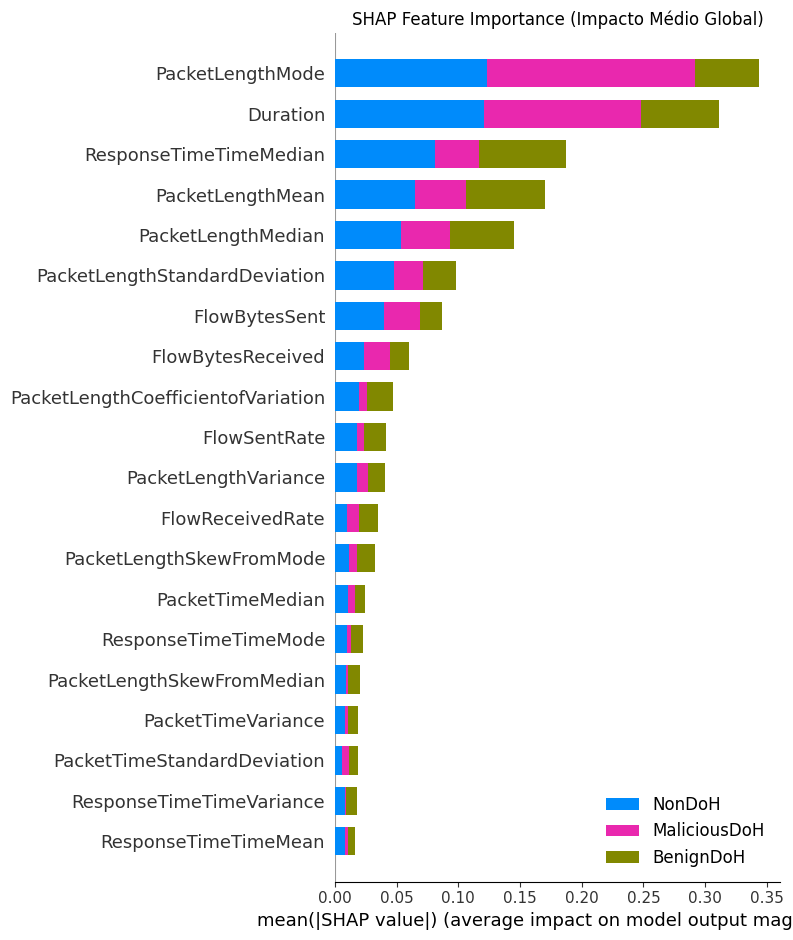

In [ ]:
# Feature Importances

plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance (Impacto Médio Global)")
shap.summary_plot(shap_values, X_test_sample_df, plot_type="bar", class_names=classes_do_modelo)

<Figure size 640x480 with 0 Axes>

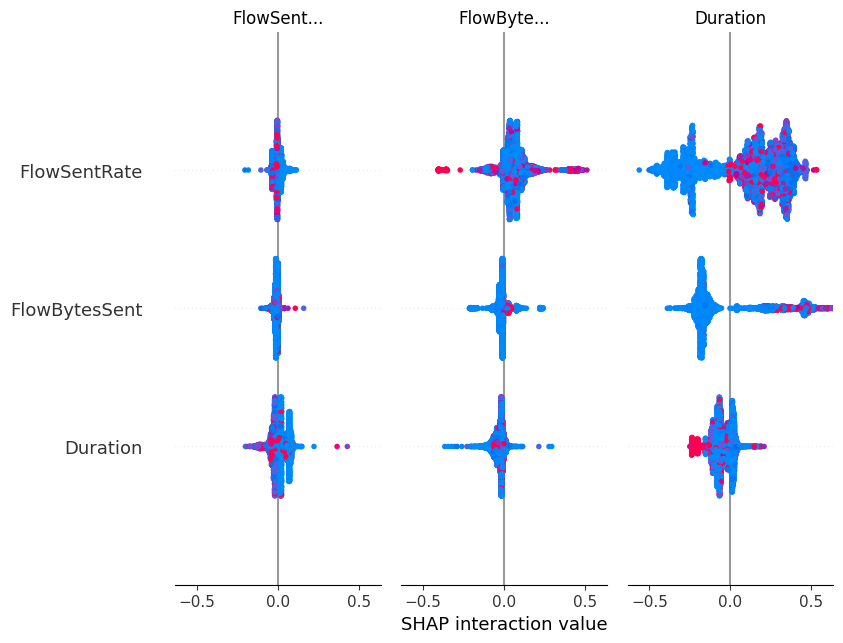

In [ ]:
# Summary Plot

fig = plt.figure()
shap.summary_plot(shap_values, X_test_sample_df, max_display=10, show=False)

plt.gcf().set_size_inches(25,6)
plt.show()

### CIRA-CIC-HKD L1 + L2 + L3

Aqui começa a nossa proposta experimental para a arquitetura. Ao "afunilarmos" as instâncias maliciosas do dataset de forma que as labels MaliciousDoH se dividam em 6 novas labels (MaliciousDoH_dns2tcp, MaliciousDoH_iodine, MaliciousDoH_dnstt, MaliciousDoH_dnscat2, MaliciousDoH_tcp_over_dns, MaliciousDoH_tuns) - as respectivas ferramentas de tunneling que geraram cada um dos exemplos -, chegamos a um problema de classificação com 8 classes.

O "afunilamento" das classes também nos leva a um novo desbalanceamento, que endereçamos de forma um pouco diferente da forma que os autores utilizam. Enquanto os autores dividem as instâncias da classe majoritária (NonDoH) em 3 partições de dados e utilizam o SMOTE nas outras duas classes para sair da proporção 45:1:18 para 15:12:12, nos deparamos com a proporção 45:8:2:2:2:2:1:1. Dividir a classe majoritária em 3 subconjuntos, assim como fizeram os autores, ainda nos levaria a um cenário bastante desbalanceado (15:8:2:2:2:2:1:1). Por isso, decidimos dividí-la em 5 subconjuntos, e aplicar o SMOTE nas demais classes, de forma que cada subconjunto siga a proporção 9:8:2:2:2:2:1:1 inicialmente, e após o SMOTE, fiquem balanceados de acordo com a proporção 1:1:1:1:1:1:1:1.

In [ ]:
# Cross Validation
cv = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)

meta_features_l3 = []
meta_labels_l3 = []

CLASSE_MAJORITARIA = 'NonDoH'
CLASSE_MALICIOUS_DNS2TCP = 'MaliciousDoH_dns2tcp' # Classe *maliciosa* majoritária
CLASSE_MALICIOUS_IODINE = 'MaliciousDoH_iodine'
CLASSE_MALICIOUS_DNSTT = 'MaliciousDoH_dnstt'
CLASSE_MALICIOUS_DNSCAT2 = 'MaliciousDoH_dnscat2'
CLASSE_MALICIOUS_TCPOVERDNS = 'MaliciousDoH_tcp_over_dns'
CLASSE_MALICIOUS_TUNS = 'MaliciousDoH_tuns'
CLASSE_BENIGN = 'BenignDoH'

contador_fold = 1

# Loop sobre os 90% dos dados de treino
for train_idx, val_idx in cv.split(X_train_cira_l1_l2_l3, y_train_cira_l1_l2_l3):

    print(f'Processando fold {contador_fold}/10')

    # Separação dos dados do fold atual
    X_train_fold = X_train_cira_l1_l2_l3.iloc[train_idx].copy()
    y_train_fold = y_train_cira_l1_l2_l3.iloc[train_idx].copy()

    X_val_fold = X_train_cira_l1_l2_l3.iloc[val_idx].copy()
    y_val_fold = y_train_cira_l1_l2_l3.iloc[val_idx].copy()

    # Juntando os dados de novo para facilitar a partição
    df_train_fold = X_train_fold.copy()
    df_train_fold['Label'] = y_train_fold

    # Separação das classes
    df_majoritaria = df_train_fold[df_train_fold['Label'] == CLASSE_MAJORITARIA]
    df_malicious_dns2tcp = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_DNS2TCP]
    df_malicious_iodine = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_IODINE]
    df_malicious_dnstt = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_DNSTT]
    df_malicious_dnscat2 = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_DNSCAT2]
    df_malicious_tcpoverdns = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_TCPOVERDNS]
    df_malicious_tuns = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_TUNS]
    df_benign = df_train_fold[df_train_fold['Label'] == CLASSE_BENIGN]

    chunks_major = np.array_split(df_majoritaria, 5)

    preds_proba_rfs = []

    for i, chunk in enumerate(chunks_major):
        subconj_df = pd.concat([chunk, df_malicious_dns2tcp, df_malicious_iodine, df_malicious_dnstt, df_malicious_dnscat2, df_malicious_tcpoverdns, df_malicious_tuns, df_benign]).sample(frac=1, random_state=42)

        # Quantidade de instâncias da segunda classe majoritária
        qtd_malicious_dns2tcp = len(df_malicious_dns2tcp)

        X_subconj = subconj_df.drop(columns=['Label'])
        y_subconj = subconj_df['Label']

        # Aplicando o SMOTE para balancear o subconjunto
        smote = SMOTE(sampling_strategy={CLASSE_BENIGN: qtd_malicious_dns2tcp,
                                         CLASSE_MALICIOUS_IODINE: qtd_malicious_dns2tcp,
                                         CLASSE_MALICIOUS_DNSTT: qtd_malicious_dns2tcp,
                                         CLASSE_MALICIOUS_DNSCAT2: qtd_malicious_dns2tcp,
                                         CLASSE_MALICIOUS_TCPOVERDNS: qtd_malicious_dns2tcp,
                                         CLASSE_MALICIOUS_TUNS: qtd_malicious_dns2tcp}, random_state=42)
        X_balanc, y_balanc = smote.fit_resample(X_subconj, y_subconj)

        contagem_classes_antes = y_subconj.value_counts()
        proporcao_antes = (contagem_classes_antes / contagem_classes_antes.min()).round().astype(int)
        print(f'[FOLD {contador_fold}] Proporção de classes para o subconjunto {i} (antes do SMOTE): {':'.join(map(str, proporcao_antes.values))}')
        print(f'[FOLD {contador_fold}] Contagem de instâncias para o subconjunto {i} (antes do SMOTE) {y_subconj.value_counts()}')

        contagem_classes_depois = y_balanc.value_counts()
        proporcao_depois = (contagem_classes_depois / contagem_classes_depois.min()).round().astype(int)
        print(f'[FOLD {contador_fold}] Proporção de classes para o subconjunto {i} (depois do SMOTE): {':'.join(map(str, proporcao_depois.values))}')
        print(f'[FOLD {contador_fold}] Contagem de instâncias para o subconjunto {i} (depois do SMOTE) {y_balanc.value_counts()}')

        # Normalizando
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_balanc)
        X_val_scaled = scaler.transform(X_val_fold)

        # Treinando o RF para a partição atual
        rf = RandomForestClassifier(n_estimators=10, max_features=28, random_state=42)
        rf.fit(X_train_scaled, y_balanc)

        preds_proba = rf.predict_proba(X_val_scaled)

        preds_proba_np = cp.asnumpy(preds_proba.values) if hasattr(preds_proba, 'values') else cp.asnumpy(preds_proba)
        preds_proba_rfs.append(preds_proba_np)

    fold_meta_features_l3 = np.hstack(preds_proba_rfs)

    meta_features_l3.append(fold_meta_features_l3)
    meta_labels_l3.append(y_val_fold.values)

    print(f"Fold {contador_fold} finalizado com sucesso")
    contador_fold += 1

X_meta_train_l3 = np.vstack(meta_features_l3)
y_meta_train_l3 = np.concatenate(meta_labels_l3)

meta_model_l3 = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
meta_model_l3.fit(X_meta_train_l3, y_meta_train_l3)

Processando fold 1/10
[FOLD 1] Proporção de classes para o subconjunto 0 (antes do SMOTE): 9:8:2:2:2:2:1:1
[FOLD 1] Contagem de instâncias para o subconjunto 0 (antes do SMOTE) Label
NonDoH                       144149
MaliciousDoH_dns2tcp         135503
MaliciousDoH_iodine           37685
MaliciousDoH_dnstt            37324
MaliciousDoH_dnscat2          28951
MaliciousDoH_tcp_over_dns     24332
MaliciousDoH_tuns             23522
BenignDoH                     15994
Name: count, dtype: int64
[FOLD 1] Proporção de classes para o subconjunto 0 (depois do SMOTE): 1:1:1:1:1:1:1:1
[FOLD 1] Contagem de instâncias para o subconjunto 0 (depois do SMOTE) Label
NonDoH                       144149
MaliciousDoH_dnscat2         135503
MaliciousDoH_tuns            135503
MaliciousDoH_dns2tcp         135503
MaliciousDoH_iodine          135503
MaliciousDoH_tcp_over_dns    135503
BenignDoH                    135503
MaliciousDoH_dnstt           135503
Name: count, dtype: int64
[FOLD 1] Proporção de clas

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [ ]:
# Treinando a base completa

df_train_completa = X_train_cira_l1_l2_l3.copy()
df_train_completa['Label'] = y_train_cira_l1_l2_l3

# Separação das classes
df_majoritaria_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MAJORITARIA]
df_malicious_dns2tcp_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_DNS2TCP]
df_malicious_iodine_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_IODINE]
df_malicious_dnstt_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_DNSTT]
df_malicious_dnscat2_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_DNSCAT2]
df_malicious_tcpoverdns_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_TCPOVERDNS]
df_malicious_tuns_completa = df_train_fold[df_train_fold['Label'] == CLASSE_MALICIOUS_TUNS]
df_benign_completa = df_train_fold[df_train_fold['Label'] == CLASSE_BENIGN]

chunks_major_completa_l3 = np.array_split(df_majoritaria_completa, 5)

# Listas para guardar os modelos e scalers finais (usados no teste)
final_rfs_l3 = []
final_scalers_l3 = []

for i, chunk in enumerate(chunks_major_completa_l3, 1):
    subconj_df = pd.concat([chunk, df_malicious_dns2tcp, df_malicious_iodine, df_malicious_dnstt, df_malicious_dnscat2, df_malicious_tcpoverdns, df_malicious_tuns, df_benign]).sample(frac=1, random_state=42)

    # Quantidade de instâncias maliciosas
    qtd_malicious_dns2tcp = len(df_malicious_dns2tcp)

    X_subconj = subconj_df.drop(columns=['Label'])
    y_subconj = subconj_df['Label']

    # SMOTE
    smote = SMOTE(sampling_strategy={CLASSE_BENIGN: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_IODINE: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_DNSTT: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_DNSCAT2: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_TCPOVERDNS: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_TUNS: qtd_malicious_dns2tcp}, random_state=42)
    X_balanc, y_balanc = smote.fit_resample(X_subconj, y_subconj)

    contagem_classes_antes = y_subconj.value_counts()
    proporcao_antes = (contagem_classes_antes / contagem_classes_antes.min()).round().astype(int)
    print(f'Proporção de classes (antes do SMOTE): {':'.join(map(str, proporcao_antes.values))}')

    contagem_classes_depois = y_balanc.value_counts()
    proporcao_depois = (contagem_classes_depois / contagem_classes_depois.min()).round().astype(int)
    print(f'Proporção de classes (depois do SMOTE): {':'.join(map(str, proporcao_depois.values))}')


    # Movendo para a GPU e normalizando
    X_balanc_gpu = cudf.DataFrame(X_balanc)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_balanc_gpu)

    # Treinando o RF
    rf = RandomForestClassifier(n_estimators=10, max_features=28, random_state=42)
    rf.fit(X_train_scaled, y_balanc)

    # Guardando as estruturas
    final_rfs_l3.append(rf)
    final_scalers_l3.append(scaler)
    print(f"Random Forest final {i}/5 treinado com sucesso")

Proporção de classes (antes do SMOTE): 9:8:2:2:2:2:1:1
Proporção de classes (depois do SMOTE): 1:1:1:1:1:1:1:1
Random Forest final 1/3 treinado com sucesso
Proporção de classes (antes do SMOTE): 9:8:2:2:2:2:1:1
Proporção de classes (depois do SMOTE): 1:1:1:1:1:1:1:1
Random Forest final 2/3 treinado com sucesso
Proporção de classes (antes do SMOTE): 9:8:2:2:2:2:1:1
Proporção de classes (depois do SMOTE): 1:1:1:1:1:1:1:1
Random Forest final 3/3 treinado com sucesso
Proporção de classes (antes do SMOTE): 9:8:2:2:2:2:1:1
Proporção de classes (depois do SMOTE): 1:1:1:1:1:1:1:1
Random Forest final 4/3 treinado com sucesso
Proporção de classes (antes do SMOTE): 9:8:2:2:2:2:1:1
Proporção de classes (depois do SMOTE): 1:1:1:1:1:1:1:1
Random Forest final 5/3 treinado com sucesso


In [ ]:
# Avaliando no conjunto de testes
test_meta_features_l3 = []

# Envia o X_test para um DataFrame do cuDF para processar na GPU
X_test_gpu_l3 = cudf.DataFrame(X_test_cira_l1_l2_l3)

for i in range(5):
    # Aplica o scaler específico do submodelo i
    X_test_scaled = final_scalers_l3[i].transform(X_test_gpu_l3)

    # Prediz as probabilidades usando o RF final correspondente
    preds_proba = final_rfs_l3[i].predict_proba(X_test_scaled)

    # Converte o resultado de volta para array do NumPy
    preds_proba_np = cp.asnumpy(preds_proba.values) if hasattr(preds_proba, 'values') else cp.asnumpy(preds_proba)
    test_meta_features_l3.append(preds_proba_np)

# Concatena as probabilidades
X_meta_test_l3 = np.hstack(test_meta_features_l3)

# A regressão logística faz a predição final
y_pred_final_l3 = meta_model_l3.predict(X_meta_test_l3)

print(confusion_matrix(y_test_cira_l1_l2_l3, y_pred_final_l3))
print('')
print(classification_report(y_test_cira_l1_l2_l3, y_pred_final_l3))

[[ 1812     1     1     0     0     0     0   161]
 [    5 16378   203     0   140     0     0     3]
 [    1    29  3324     0   216     0     0     4]
 [    0     0     0  4608     0     0     0     0]
 [    1    21   268     0  4358     0     0     4]
 [    0     0     0     0     0  3004     0     0]
 [    0     0     0     2     0     0  2902     0]
 [  349     2    22     1    19     1     0 88587]]

                           precision    recall  f1-score   support

                BenignDoH       0.84      0.92      0.87      1975
     MaliciousDoH_dns2tcp       1.00      0.98      0.99     16729
     MaliciousDoH_dnscat2       0.87      0.93      0.90      3574
       MaliciousDoH_dnstt       1.00      1.00      1.00      4608
      MaliciousDoH_iodine       0.92      0.94      0.93      4652
MaliciousDoH_tcp_over_dns       1.00      1.00      1.00      3004
        MaliciousDoH_tuns       1.00      1.00      1.00      2904
                   NonDoH       1.00      1.00      1

#### xAI

In [ ]:
# Como o modelo foi treinado na GPU, por questões de compatibilidade com a biblioteca SHAP, teremos que "replicá-lo" na CPU
chunk_1 = chunks_major_completa_l3[0]
subconj_df_shap_l3 = pd.concat([chunk_1, df_malicious_dns2tcp, df_malicious_iodine, df_malicious_dnstt, df_malicious_dnscat2, df_malicious_tcpoverdns, df_malicious_tuns, df_benign]).sample(frac=1, random_state=42)

X_subconj_shap_l3 = subconj_df_shap_l3.drop(columns=['Label'])
y_subconj_shap_l3 = subconj_df_shap_l3['Label']

qtd_malicious_dns2tcp = len(df_malicious_dns2tcp)
smote_shap_l3 = SMOTE(sampling_strategy={CLASSE_BENIGN: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_IODINE: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_DNSTT: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_DNSCAT2: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_TCPOVERDNS: qtd_malicious_dns2tcp,
                                     CLASSE_MALICIOUS_TUNS: qtd_malicious_dns2tcp}, random_state=42)
X_balanc_shap_l3, y_balanc_shap_l3 = smote_shap_l3.fit_resample(X_subconj_shap_l3, y_subconj_shap_l3)

scaler_shap_l3 = ScalerCPU()
X_train_scaled_shap_l3 = scaler_shap_l3.fit_transform(X_balanc_shap_l3)

rf_shap_l3 = RandomForestCPU(n_estimators=10, max_features=28, random_state=42)
rf_shap_l3.fit(X_train_scaled_shap_l3, y_balanc_shap_l3)

# Aplicação do SHAP em uma amostra de teste
X_test_sample_l3 = X_test_cira_l1_l2_l3.sample(n=5000, random_state=42)
X_test_sample_scaled_l3 = scaler_shap_l3.transform(X_test_sample_l3)

X_test_sample_df_l3 = pd.DataFrame(X_test_sample_scaled_l3, columns=X_test_cira_l1_l2_l3.columns)

explainer_l3 = shap.TreeExplainer(rf_shap_l3)
shap_values_l3 = explainer_l3.shap_values(X_test_sample_df_l3)

classes_do_modelo_l3 = rf_shap_l3.classes_
print(f"Ordem das classes no modelo: {classes_do_modelo_l3}")

Ordem das classes no modelo: ['BenignDoH' 'MaliciousDoH_dns2tcp' 'MaliciousDoH_dnscat2'
 'MaliciousDoH_dnstt' 'MaliciousDoH_iodine' 'MaliciousDoH_tcp_over_dns'
 'MaliciousDoH_tuns' 'NonDoH']


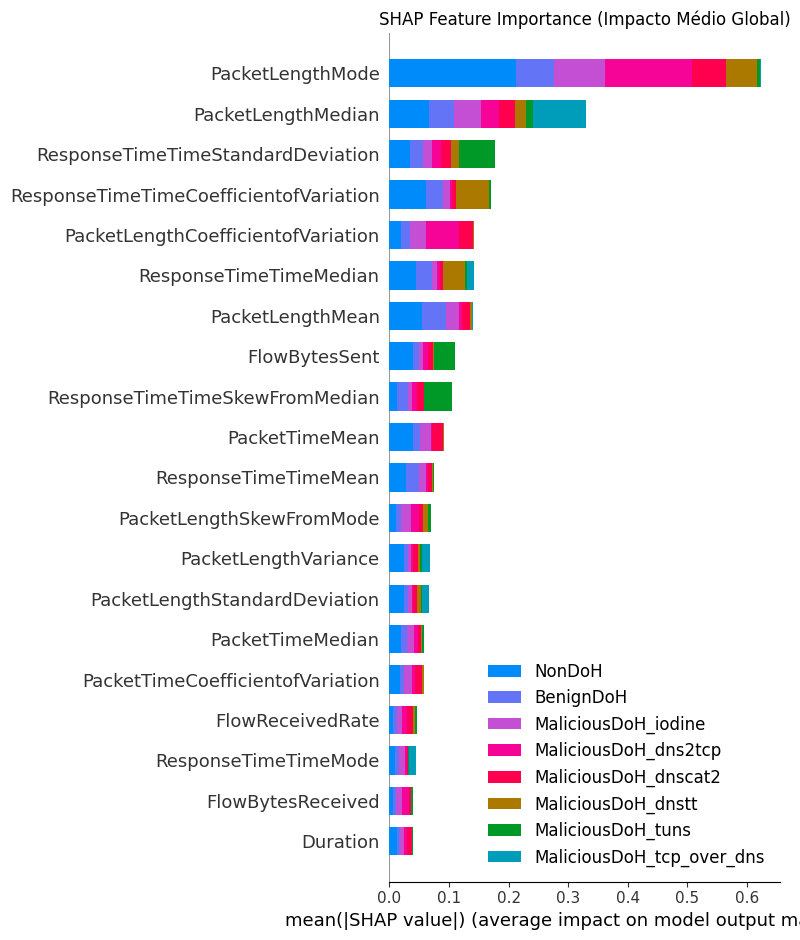

In [ ]:
# Feature Importances

plt.figure(figsize=(10, 6))
plt.title("SHAP Feature Importance (Impacto Médio Global)")
shap.summary_plot(shap_values_l3, X_test_sample_df_l3, plot_type="bar", class_names=classes_do_modelo_l3)

<Figure size 640x480 with 0 Axes>

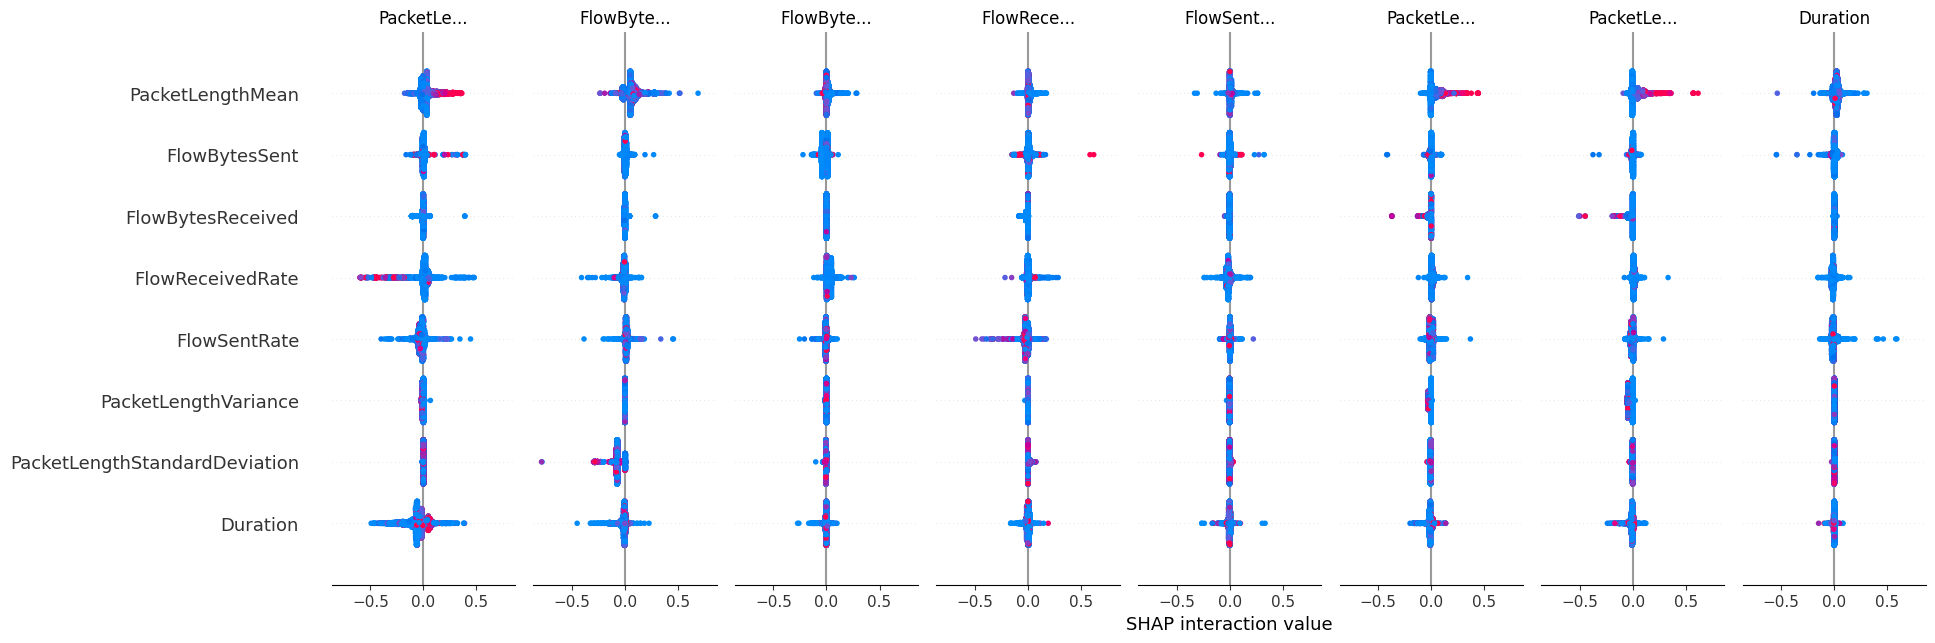

In [ ]:
# Summary Plot

fig = plt.figure()
shap.summary_plot(shap_values_l3, X_test_sample_df_l3, max_display=10, show=False)

plt.gcf().set_size_inches(25,6)
plt.show()